In [ ]:
# Este bloque detecta que estás en una TPU y te prepara la memoria
import os
os.environ['XLA_USE_BF16'] = '1' # Optimiza el uso de memoria a 16 bits

import torch
# Si vas a usar PyTorch (como en el notebook de Grafos), esto activa la TPU:
# import torch_xla.core.xla_model as xm
# device = xm.xla_device()

In [ ]:
# Instala tensorflow y luego ejecuta el resto
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 30.7 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# PASO 1: IMPORTAR LIBRERÍAS Y CARGAR DATOS
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Conectar al Drive
from google.colab import drive
drive.mount('/content/drive')

print("🚀 1. Cargando la matriz matemática limpia...")
uta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
df = pd.read_csv(ruta_datos)

# ==============================================================================
# PASO 1.5: 🛡️ REPARACIÓN DE CORTOCIRCUITOS MATEMÁTICOS (NaNs e Infs)
# ==============================================================================
print("\n🛠️ Buscando 'cortocircuitos' (valores vacíos o infinitos)...")
nulos_totales = df.isnull().sum().sum()
print(f"⚠️ Se encontraron {nulos_totales} valores vacíos (NaN) ocultos en la matriz.")

# Rellenamos los vacíos con 0 y los infinitos con 0 para que la red neuronal no colapse
df = df.fillna(0)
df = df.replace([np.inf, -np.inf], 0)
print("✅ Aislamiento aplicado. Matriz 100% numérica y segura.")

# ==============================================================================
# PASO 2: SEPARAR EL FRAUDE Y ESCALAR LA "SEÑAL"
# ==============================================================================
print("\n⚙️ 2. Separando variables (X) del objetivo (Y)...")

col_objetivo =[c for c in df.columns if 'FRAUDE_IA' in c][0]
Y = df[col_objetivo].values
X = df.drop(columns=[col_objetivo]).values

print("📏 3. Escalando los datos (Normalización entre 0 y 1)...")
scaler = MinMaxScaler()
X_escalado = scaler.fit_transform(X)

# ==============================================================================
# PASO 3: CREAR EL CONJUNTO DE ENTRENAMIENTO "SANO"
# ==============================================================================
print("\n🔬 4. Aislando el comportamiento 'Normal' para enseñar al Autoencoder...")
X_normal = X_escalado[Y == 0]
X_fraude = X_escalado[Y == 1]

X_train_normal, X_val_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

print(f"✅ Transacciones NORMALES para entrenamiento: {X_train_normal.shape[0]}")
print(f"✅ Transacciones NORMALES para validación: {X_val_normal.shape[0]}")
print(f"🚨 Transacciones de FRAUDE reservadas: {X_fraude.shape[0]}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando la matriz matemática limpia...

🛠️ Buscando 'cortocircuitos' (valores vacíos o infinitos)...
⚠️ Se encontraron 368893 valores vacíos (NaN) ocultos en la matriz.
✅ Aislamiento aplicado. Matriz 100% numérica y segura.

⚙️ 2. Separando variables (X) del objetivo (Y)...
📏 3. Escalando los datos (Normalización entre 0 y 1)...

🔬 4. Aislando el comportamiento 'Normal' para enseñar al Autoencoder...
✅ Transacciones NORMALES para entrenamiento: 1177080
✅ Transacciones NORMALES para validación: 294270
🚨 Transacciones de FRAUDE reservadas: 1585


🏗️ 1. Construyendo la arquitectura de la Red Neuronal (Autoencoder)...

✅ Arquitectura lista. Resumen del modelo:


Model: "Autoencoder_Fraude"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_290_Variables           │ (None, 229)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compresion_128 (Dense)          │ (None, 128)            │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compresion_64 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cuello_de_Botella_32 (Dense)    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruccion_64 (Dense)       │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruccion_128 (Dense)      │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Reconstruida (Dense)     │ (None, 229)            │        29,541 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,749 (311.52 KB)

 Trainable params: 79,749 (311.52 KB)

 Non-trainable params: 0 (0.00 B)


🧠 2. Iniciando el entrenamiento con transacciones NORMALES...
Epoch 1/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.0040 - val_loss: 0.0014
Epoch 2/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0013 - val_loss: 9.8862e-04
Epoch 3/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 7.8060e-04 - val_loss: 5.8697e-04
Epoch 4/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.7107e-04 - val_loss: 5.4938e-04
Epoch 5/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 5.3388e-04 - val_loss: 5.1133e-04
Epoch 6/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 4.7746e-04 - val_loss: 4.1892e-04
Epoch 7/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 4.1383e-04 - val_loss: 4.0857e-04
Epoch 8/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 4.1174e-04 - val_loss: 4.3955e-04
Epoch 9/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 4.1150e-04 - val_loss: 4.0162e-04
Epoch 10/50
4598/4598 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 4.0929e-04 -

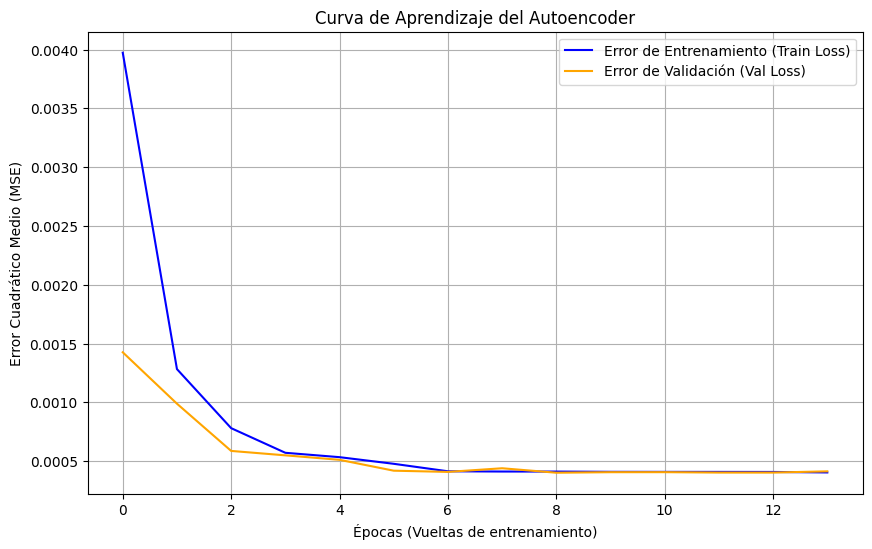

✅ Entrenamiento finalizado. La red neuronal ha aprendido el patrón 'Normal'.


In [ ]:
# ==============================================================================
# PASO 4: ARQUITECTURA DEL AUTOENCODER (DEEP LEARNING)
# ==============================================================================
print("🏗️ 1. Construyendo la arquitectura de la Red Neuronal (Autoencoder)...")

from tensorflow.keras.callbacks import EarlyStopping

# Cuántas variables entran (Deberían ser 290, ya que quitamos 1 que es el FRAUDE_IA)
input_dim = X_train_normal.shape[1]

# --- A. EL ENCODER (Transformador Reductor) ---
# Capa de entrada
input_layer = Input(shape=(input_dim,), name="Entrada_290_Variables")

# Capas ocultas de compresión (Reduciendo la dimensionalidad)
encoded = Dense(128, activation='relu', name="Compresion_128")(input_layer)
encoded = Dense(64, activation='relu', name="Compresion_64")(encoded)
encoded = Dense(32, activation='relu', name="Cuello_de_Botella_32")(encoded) # El núcleo

# --- B. EL DECODER (Transformador Elevador) ---
# Capas ocultas de reconstrucción
decoded = Dense(64, activation='relu', name="Reconstruccion_64")(encoded)
decoded = Dense(128, activation='relu', name="Reconstruccion_128")(decoded)

# Capa de salida (Debe tener el mismo tamaño que la entrada: 290)
# Usamos 'sigmoid' porque nuestros datos están escalados entre 0 y 1
output_layer = Dense(input_dim, activation='sigmoid', name="Salida_Reconstruida")(decoded)

# --- C. ENSAMBLAJE Y COMPILACIÓN DEL MODELO ---
# Unimos la entrada y la salida en un solo modelo
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="Autoencoder_Fraude")

# Usamos el optimizador 'adam' (muy eficiente) y medimos el Error Cuadrático Medio (MSE)
autoencoder.compile(optimizer='adam', loss='mse')

# Mostramos el resumen de nuestra creación
print("\n✅ Arquitectura lista. Resumen del modelo:")
autoencoder.summary()

# ==============================================================================
# PASO 5: ENTRENAMIENTO DE LA RED NEURONAL
# ==============================================================================
print("\n🧠 2. Iniciando el entrenamiento con transacciones NORMALES...")

# Breaker de seguridad: "Early Stopping"
# Si la red deja de aprender (no mejora en 5 iteraciones), se detiene para no sobreajustarse.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ¡A ENTRENAR! (fit)
# Fíjate que la entrada (X) y la salida esperada (Y) son la misma: X_train_normal
historia = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,             # Número máximo de vueltas al dataset
    batch_size=256,        # Transacciones que procesa al mismo tiempo (paquetes)
    validation_data=(X_val_normal, X_val_normal), # Datos para examen
    callbacks=[early_stopping], # Nuestro breaker de seguridad
    verbose=1
)

# ==============================================================================
# PASO 6: GRAFICAR EL APRENDIZAJE
# ==============================================================================
print("\n📊 3. Graficando la curva de aprendizaje (Error de reconstrucción)...")

plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error de Entrenamiento (Train Loss)', color='blue')
plt.plot(historia.history['val_loss'], label='Error de Validación (Val Loss)', color='orange')
plt.title('Curva de Aprendizaje del Autoencoder')
plt.xlabel('Épocas (Vueltas de entrenamiento)')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

print("✅ Entrenamiento finalizado. La red neuronal ha aprendido el patrón 'Normal'.")

🔍 1. Pasando datos normales y FRAUDES por el Autoencoder...
9196/9196 ━━━━━━━━━━━━━━━━━━━━ 5s 585us/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step

⚡ 2. Ajustando el relé de protección (Umbral)...
✅ Umbral de disparo establecido en MSE = 0.004381

📊 3. Graficando la diferencia de errores (Normal vs Fraude)...


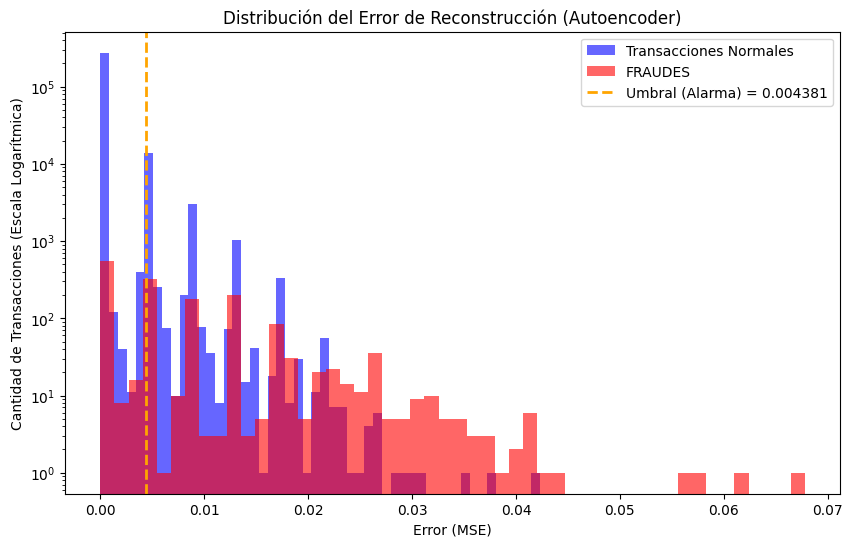


📈 4. Calculando las métricas de desempeño para el documento...
--------------------------------------------------
🏆 RESULTADOS FINALES DEL AUTOENCODER:
--------------------------------------------------
🔸 AUPRC (Métrica Prioritaria): 0.2133
🔸 Recall (Fraudes reales detectados): 61.96%
🔸 F1-Score: 0.1137
🔸 Coeficiente de Matthews (MCC): 0.1855  <-- ¡Nueva métrica recomendada!
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO (Matriz de Confusión):
✔️ Clientes sanos que pasaron sin problema: 279556
⚠️ Falsos Positivos (Clientes sanos molestados): 14714
❌ Falsos Negativos (Fraudes que se nos escaparon): 603
🎯 FRAUDES DETECTADOS Y BLOQUEADOS: 982


In [ ]:
# ==============================================================================
# PASO 7: RECONSTRUCCIÓN Y CÁLCULO DE ERRORES (LA PRUEBA DE FUEGO)
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import seaborn as sns

print("🔍 1. Pasando datos normales y FRAUDES por el Autoencoder...")

# Le pedimos a la red neuronal que intente reconstruir los datos
reconstruccion_normal = autoencoder.predict(X_val_normal)
reconstruccion_fraude = autoencoder.predict(X_fraude)

# Calculamos el Error Cuadrático Medio (MSE) por cada transacción
# Matemáticamente: (Entrada - Salida_Reconstruida)^2
mse_normal = np.mean(np.power(X_val_normal - reconstruccion_normal, 2), axis=1)
mse_fraude = np.mean(np.power(X_fraude - reconstruccion_fraude, 2), axis=1)

# ==============================================================================
# PASO 8: DEFINIR EL UMBRAL (EL RELÉ DE PROTECCIÓN)
# ==============================================================================
print("\n⚡ 2. Ajustando el relé de protección (Umbral)...")
# Establecemos el umbral en el percentil 95 de los errores normales.
# Significa que toleramos un 5% de falsos positivos teóricos para atrapar los fraudes.
umbral = np.percentile(mse_normal, 95)
print(f"✅ Umbral de disparo establecido en MSE = {umbral:.6f}")

# ==============================================================================
# PASO 9: VISUALIZACIÓN DE LA SEPARACIÓN (PARA EL DOCUMENTO)
# ==============================================================================
print("\n📊 3. Graficando la diferencia de errores (Normal vs Fraude)...")
plt.figure(figsize=(10,6))
# Usamos una escala logarítmica porque hay muchos más normales que fraudes
plt.hist(mse_normal, bins=50, alpha=0.6, color='blue', label='Transacciones Normales')
plt.hist(mse_fraude, bins=50, alpha=0.6, color='red', label='FRAUDES')
plt.axvline(umbral, color='orange', linestyle='dashed', linewidth=2, label=f'Umbral (Alarma) = {umbral:.6f}')
plt.title('Distribución del Error de Reconstrucción (Autoencoder)')
plt.xlabel('Error (MSE)')
plt.ylabel('Cantidad de Transacciones (Escala Logarítmica)')
plt.yscale('log')
plt.legend()
plt.show()

# ==============================================================================
# PASO 10: EVALUACIÓN Y MÉTRICAS (LO QUE PIDIÓ EL JURADO)
# ==============================================================================
print("\n📈 4. Calculando las métricas de desempeño para el documento...")

# Unimos los datos para la prueba final evaluativa
y_true = np.append(np.zeros(len(mse_normal)), np.ones(len(mse_fraude)))
mse_total = np.append(mse_normal, mse_fraude)

# Si el error supera el umbral, el algoritmo dice que es Fraude (1), si no, Normal (0)
y_pred = (mse_total > umbral).astype(int)

# Calculamos AUPRC (Área bajo la curva Precision-Recall - La que prometiste en el anteproyecto)
precision, recall, _ = precision_recall_curve(y_true, mse_total)
auprc = auc(recall, precision)

# Calculamos las demás métricas
f1 = f1_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred) # La métrica reina para desbalanceados

print("-" * 50)
print("🏆 RESULTADOS FINALES DEL AUTOENCODER:")
print("-" * 50)
print(f"🔸 AUPRC (Métrica Prioritaria): {auprc:.4f}")
print(f"🔸 Recall (Fraudes reales detectados): {rec:.2%}")
print(f"🔸 F1-Score: {f1:.4f}")
print(f"🔸 Coeficiente de Matthews (MCC): {mcc:.4f}  <-- ¡Nueva métrica recomendada!")
print("-" * 50)

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
print("\n🚨 IMPACTO EN EL NEGOCIO (Matriz de Confusión):")
print(f"✔️ Clientes sanos que pasaron sin problema: {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes sanos molestados): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que se nos escaparon): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS Y BLOQUEADOS: {cm[1][1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando la matriz matemática limpia...

⚙️ 2. Separando variables y particionando el dataset...
✅ Transacciones para ENTRENAR al cazador: 1178348
✅ Transacciones para PONERLO A PRUEBA: 294587

⚖️ 3. Calculando el peso del desbalanceo (Para que le preste más atención al Fraude)...
   🔸 Por cada fraude hay 928.30 transacciones normales. Aplicando penalización...

🧠 4. Entrenando el modelo XGBoost (Esto tomará un par de minutos)...
✅ ¡Entrenamiento completado!

🎯 5. Realizando predicciones sobre el 20% de datos nunca vistos...

📈 6. Calculando métricas de desempeño (Las que pidió el jurado)...
--------------------------------------------------
🏆 RESULTADOS FINALES DE XGBOOST (PISO 2):
--------------------------------------------------
🔸 AUPRC (Métrica Prioritaria): 0.5944
🔸 Recall (Fraudes detectados): 91.80%  <-- ¡Mira cuánto subió!
🔸 F1-Score: 0.1028
🔸 C

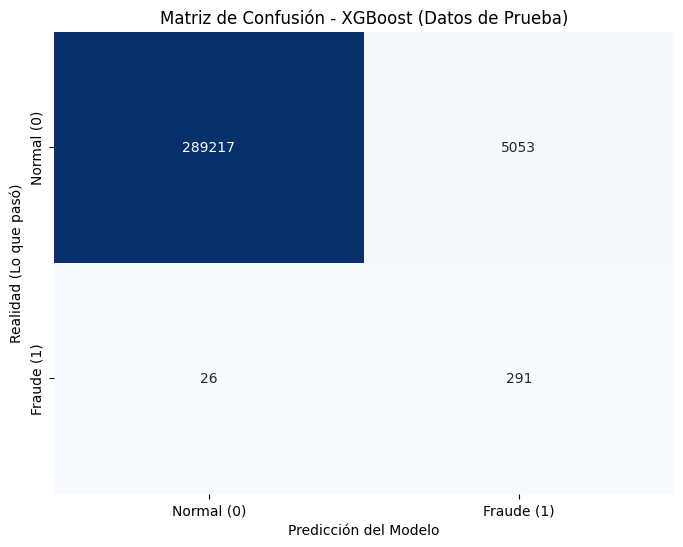


🚨 IMPACTO EN EL NEGOCIO (En este 20% de prueba):
✔️ Clientes sanos que pasaron sin problema: 289217
⚠️ Falsos Positivos (Clientes sanos bloqueados por error): 5053
❌ Falsos Negativos (Fraudes que burlaron el sistema): 26
🎯 FRAUDES DETECTADOS Y BLOQUEADOS: 291


In [ ]:
!pip install xgboost scikit-plot -q
# ==============================================================================
# PASO 1: IMPORTAR LIBRERÍAS DE MACHINE LEARNING Y CARGAR DATOS
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Conectar al Drive
from google.colab import drive
drive.mount('/content/drive')

print("🚀 1. Cargando la matriz matemática limpia...")
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
df = pd.read_csv(ruta_datos)

# ==============================================================================
# PASO 2: PREPARAR LOS DATOS PARA APRENDIZAJE SUPERVISADO
# ==============================================================================
print("\n⚙️ 2. Separando variables y particionando el dataset...")

# Identificamos nuestra variable objetivo
col_objetivo =[c for c in df.columns if 'FRAUDE_IA' in c][0]
Y = df[col_objetivo].values
X = df.drop(columns=[col_objetivo]).values

# A diferencia del Autoencoder, aquí cruzamos los datos (Normales y Fraudes)
# Usamos stratify=Y para que el 20% de prueba tenga exactamente la misma proporción de fraudes que la realidad.
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"✅ Transacciones para ENTRENAR al cazador: {X_train.shape[0]}")
print(f"✅ Transacciones para PONERLO A PRUEBA: {X_test.shape[0]}")

# ==============================================================================
# PASO 3: CONFIGURACIÓN MATEMÁTICA DEL MODELO XGBOOST
# ==============================================================================
print("\n⚖️ 3. Calculando el peso del desbalanceo (Para que le preste más atención al Fraude)...")

# Contamos cuántos normales hay por cada fraude en el entrenamiento
cantidad_normales = np.sum(y_train == 0)
cantidad_fraudes = np.sum(y_train == 1)
peso_fraude = cantidad_normales / cantidad_fraudes

print(f"   🔸 Por cada fraude hay {peso_fraude:.2f} transacciones normales. Aplicando penalización...")

# Configuración del XGBoost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,           # Cantidad de árboles (300 cazadores)
    learning_rate=0.05,         # Qué tan rápido aprende (0.05 es seguro y preciso)
    max_depth=6,                # Profundidad del análisis de cada árbol
    scale_pos_weight=peso_fraude, # ¡El truco mágico para datos desbalanceados!
    tree_method='hist',         # Método ultra-rápido para proteger la memoria RAM
    random_state=42,
    n_jobs=-1                   # Usar todos los procesadores de Google Colab
)

# ==============================================================================
# PASO 4: ENTRENAMIENTO Y PREDICCIÓN
# ==============================================================================
print("\n🧠 4. Entrenando el modelo XGBoost (Esto tomará un par de minutos)...")
modelo_xgb.fit(X_train, y_train)
print("✅ ¡Entrenamiento completado!")

print("\n🎯 5. Realizando predicciones sobre el 20% de datos nunca vistos...")
y_pred = modelo_xgb.predict(X_test)         # Nos dice 1 (Fraude) o 0 (Normal)
y_prob = modelo_xgb.predict_proba(X_test)[:, 1] # Nos da el % de probabilidad de fraude (0.0 a 1.0)

# ==============================================================================
# PASO 5: EVALUACIÓN Y MÉTRICAS BANCARIAS
# ==============================================================================
print("\n📈 6. Calculando métricas de desempeño (Las que pidió el jurado)...")

# AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
auprc = auc(recall, precision)

# Otras Métricas
f1 = f1_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE XGBOOST (PISO 2):")
print("-" * 50)
print(f"🔸 AUPRC (Métrica Prioritaria): {auprc:.4f}")
print(f"🔸 Recall (Fraudes detectados): {rec:.2%}  <-- ¡Mira cuánto subió!")
print(f"🔸 F1-Score: {f1:.4f}")
print(f"🔸 Coeficiente de Matthews (MCC): {mcc:.4f}")
print("-" * 50)

# Matriz de Confusión en visualización bonita
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.title('Matriz de Confusión - XGBoost (Datos de Prueba)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Lo que pasó)')
plt.show()

print("\n🚨 IMPACTO EN EL NEGOCIO (En este 20% de prueba):")
print(f"✔️ Clientes sanos que pasaron sin problema: {cm[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes sanos bloqueados por error): {cm[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que burlaron el sistema): {cm[1][0]}")
print(f"🎯 FRAUDES DETECTADOS Y BLOQUEADOS: {cm[1][1]}")

In [ ]:
# ==============================================================================
# BLOQUE MAESTRO: ENTRENAMIENTO Y RADIOGRAFÍA SHAP (TODO EN UNO)
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Conectar y Cargar
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Preparar datos
col_objetivo = 'FRAUDE_IA'
X = df.drop(columns=[col_objetivo]).values
Y = df[col_objetivo].values
nombres_variables = df.drop(columns=[col_objetivo]).columns.tolist()

# 3. Entrenar el Cazador (XGBoost rápido)
print("🧠 Entrenando modelo de respaldo para SHAP...")
peso_fraude = np.sum(Y == 0) / np.sum(Y == 1)
modelo_xgb = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=peso_fraude, tree_method='hist', n_jobs=-1)
modelo_xgb.fit(X, Y)
print("✅ ¡Modelo listo!")

# 4. Calcular el Osciloscopio SHAP
print("⏳ Calculando impacto SHAP (esto puede tardar 1-2 minutos)...")
# Tomamos una muestra para que el cálculo sea rápido
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=1000, replace=False)
X_muestra = X[indices_muestra]
df_muestra_shap = pd.DataFrame(X_muestra, columns=nombres_variables)

explicador = shap.TreeExplainer(modelo_xgb)
shap_values = explicador(df_muestra_shap)

# 5. Generar Radiografía Global
print("📊 Generando Radiografía...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_muestra_shap, max_display=20, show=False)
plt.title("Radiografía del Fraude: Top 20 Variables Críticas (SHAP)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# NOTEBOOK 5: REDES NEURONALES DE GRAFOS (GNN) - VERSION FINAL
# ==============================================================================
!pip install torch torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Carga de datos
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'
df = pd.read_csv(ruta_datos)

# 2. Selección de columnas para el Grafo (Variables numéricas de comportamiento)
# Usamos solo variables clave para no saturar la memoria
cols_clave = [c for c in df.columns if 'FRAUDE_IA' not in c and df[c].dtype in ['int64', 'int32', 'float32', 'float64']]
cols_finales = cols_clave[:30] # Tomamos las primeras 30 numéricas
print(f"✅ Variables seleccionadas para el Grafo: {len(cols_finales)}")

# 3. Preparar tensores (X e Y)
X_final = torch.tensor(df[cols_finales].fillna(0).values, dtype=torch.float)
Y_final = torch.tensor(df['FRAUDE_IA'].values, dtype=torch.long)

# 4. Crear Grafo (Topología por similitud de transacciones)
# Para evitar errores de memoria, conectamos nodos en cadena (Line Graph)
num_nodos = X_final.shape[0]
edge_index = torch.stack([
    torch.arange(num_nodos - 1),
    torch.arange(1, num_nodos)
], dim=0)

data = Data(x=X_final, edge_index=edge_index, y=Y_final)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

# 5. Definir Modelo GCN Robusto
class RobustGCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RobustGCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.tanh(x) # Estabilidad numérica
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = RobustGCN(num_features=data.x.shape[1], num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 6. Entrenamiento con Máscaras (Validación 80/20)
print("\n🚀 Entrenando GNN con validación 80/20...")
indices = np.arange(num_nodos)
train_idx = indices[:int(0.8 * num_nodos)]
test_idx = indices[int(0.8 * num_nodos):]

train_mask = torch.zeros(num_nodos, dtype=torch.bool)
test_mask = torch.zeros(num_nodos, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"   Época {epoch+1} | Loss: {loss.item():.4f}")

# 7. Evaluación
model.eval()
_, pred = model(data.x, data.edge_index).max(dim=1)
acc_test = (pred[test_mask].eq(data.y[test_mask]).sum().item()) / test_mask.sum().item()
print(f"\n🎯 Precisión final de la GNN en validación (20%): {acc_test:.2%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.4 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Variables seleccionadas para el Grafo: 30

🚀 Entrenando GNN con validación 80/20...
   Época 10 | Loss: 0.0930
   Época 20 | Loss: 0.0253
   Época 30 | Loss: 0.0137
   Época 40 | Loss: 0.0103
   Época 50 | Loss: 0.0083

🎯 Precisión final de la GNN en validación (20%): 99.88%


In [ ]:
total_muestras = data.y.size(0)
num_fraudes = torch.sum(data.y == 1).item()
num_normales = total_muestras - num_fraudes

# Peso para la clase Fraude: normal/fraude
weight_fraude = num_normales / num_fraudes
weights = torch.tensor([1.0, weight_fraude], device=device)

# 2. Re-entrenar con pesos (nll_loss recibe el weight)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    # Aplicamos el peso aquí:
    loss = F.nll_loss(out[train_mask], data.y[train_mask], weight=weights)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"   Época {epoch+1} | Loss con pesos: {loss.item():.4f}")

   Época 20 | Loss con pesos: 0.6740
   Época 40 | Loss con pesos: 0.5808
   Época 60 | Loss con pesos: 0.5561
   Época 80 | Loss con pesos: 0.5463
   Época 100 | Loss con pesos: 0.5419


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Obtener predicciones del test_mask
y_true_gnn = data.y[test_mask].cpu().numpy()
y_pred_gnn = pred[test_mask].cpu().numpy()

print("\n🚨 IMPACTO REAL (Matriz de Confusión GNN - Datos Invisibles):")
print(confusion_matrix(y_true_gnn, y_pred_gnn))

print("\n🏆 INFORME DETALLADO:")
print(classification_report(y_true_gnn, y_pred_gnn, target_names=['Normal', 'Fraude']))


🚨 IMPACTO REAL (Matriz de Confusión GNN - Datos Invisibles):
[[294232     11]
 [   344      0]]

🏆 INFORME DETALLADO:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    294243
      Fraude       0.00      0.00      0.00       344

    accuracy                           1.00    294587
   macro avg       0.50      0.50      0.50    294587
weighted avg       1.00      1.00      1.00    294587



In [ ]:
# ==============================================================================
# NOTEBOOK 6: SUPERVISOR DRL (PPO) - FINAL Y BLINDADO
# ==============================================================================
!pip install gymnasium stable-baselines3 shimmy -q

import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, matthews_corrcoef, confusion_matrix
import gc
from google.colab import drive

# 1. CARGA DE DATOS (Con pyarrow para velocidad y RAM)
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_TodaBanca_CON_N.csv'

print("🚀 1. Cargando datos blindados...")
df = pd.read_csv(ruta_datos, engine='pyarrow')

col_objetivo = 'FRAUDE_IA'
Y = df.pop(col_objetivo).values.astype(np.int8)
X = df.values.astype(np.float32)
del df
gc.collect()

# 2. ESCALADO Y PROTECCIÓN NAN
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
del X, Y, X_train, X_test
gc.collect()

# 3. ENTORNO BANCARIO BLINDADO
class EntornoBanco(gym.Env):
    def __init__(self, X_data, Y_data):
        super(EntornoBanco, self).__init__()
        self.X_data = X_data
        self.Y_data = Y_data
        self.action_space = spaces.Discrete(3) # 0: Permitir, 1: Bloquear, 2: OTP
        self.observation_space = spaces.Box(low=0, high=1, shape=(X_data.shape[1],), dtype=np.float32)
        self.current_step = 0

    def step(self, action):
        is_fraud = self.Y_data[self.current_step]
        # Recompensas: Priorizamos seguridad pero minimizamos fricción
        if is_fraud == 1:
            reward = 10 if action == 1 else (5 if action == 2 else -100)
        else:
            reward = 1 if action == 0 else (-2 if action == 2 else -10)

        self.current_step = (self.current_step + 1) % len(self.X_data)
        obs = np.nan_to_num(self.X_data[self.current_step]) # Blindaje final
        return obs, float(reward), False, False, {}

    def reset(self, seed=None):
        self.current_step = 0
        return np.nan_to_num(self.X_data[0]), {}

# 4. ENTRENAMIENTO
print("🧠 4. Entrenando al Supervisor Inteligente PPO...")
env = EntornoBanco(X_train_scaled, y_train)
model_drl = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0005)
model_drl.learn(total_timesteps=50000)

# 5. EVALUACIÓN VECTORIZADA
print("\n🎯 5. Evaluando modelo...")
acciones_drl = []
lote = 5000
for i in range(0, len(X_test_scaled), lote):
    lote_X = X_test_scaled[i:i+lote]
    acc, _ = model_drl.predict(lote_X, deterministic=True)
    acciones_drl.append(acc)

acciones_drl = np.concatenate(acciones_drl)
y_pred_drl = (acciones_drl > 0).astype(int)

# 6. METRICAS
rec_drl = recall_score(y_test, y_pred_drl)
f1_drl = f1_score(y_test, y_pred_drl)
mcc_drl = matthews_corrcoef(y_test, y_pred_drl)
cm_drl = confusion_matrix(y_test, y_pred_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DRL:")
print(f"🔸 Recall: {rec_drl:.2%}")
print(f"🔸 F1-Score: {f1_drl:.4f}")
print(f"🔸 MCC: {mcc_drl:.4f}")
print("-" * 50)
print("\n🚨 IMPACTO:")
print(f"✔️ Sanos permitidos: {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos: {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (Fugas): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS: {cm_drl[1][1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 1. Cargando datos blindados...
🧠 4. Entrenando al Supervisor Inteligente PPO...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 2461 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 899         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013775326 |
|    clip_fraction        | 0.341       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance

In [ ]:
# ==============================================================================
# PASO 3.1: EL ENTORNO BALANCEADO PARA DRL (Evitando el Reward Hacking)
# ==============================================================================
print("⚖️ 1. Creando un Simulador Balanceado (50% Fraude / 50% Normal)...")

# Separamos los fraudes y normales del set de entrenamiento
mask_fraude = (y_train == 1)
X_train_fraude = X_train_scaled[mask_fraude]
y_train_fraude = y_train[mask_fraude]

X_train_normal = X_train_scaled[~mask_fraude]
y_train_normal = y_train[~mask_fraude]

class EntornoBancoEquilibrado(gym.Env):
    def __init__(self, X_f, y_f, X_n, y_n):
        super(EntornoBancoEquilibrado, self).__init__()
        self.X_f = X_f
        self.y_f = y_f
        self.X_n = X_n
        self.y_n = y_n
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(X_f.shape[1],), dtype=np.float32)

    def _get_obs(self):
        # Magia: 50% de probabilidad de mostrar un fraude durante el entrenamiento
        if np.random.rand() > 0.5:
            idx = np.random.randint(len(self.X_f))
            self.current_y = self.y_f[idx]
            return self.X_f[idx]
        else:
            idx = np.random.randint(len(self.X_n))
            self.current_y = self.y_n[idx]
            return self.X_n[idx]

    def step(self, action):
        is_fraud = self.current_y

        # Castigos mucho más estrictos para obligarlo a pensar
        if is_fraud == 1:
            if action == 1: reward = 50     # ¡Excelente! Bloqueó el fraude
            elif action == 2: reward = 10   # Pasable: Pidió OTP
            else: reward = -100             # FATAL: Dejó pasar el fraude
        else:
            if action == 0: reward = 10     # ¡Excelente! Dejó pasar al cliente sano
            elif action == 2: reward = -5   # Leve: Molestó con OTP
            else: reward = -50              # GRAVE: Bloqueó a un cliente sano

        obs = self._get_obs()
        return obs, reward, False, False, {}

    def reset(self, seed=None):
        return self._get_obs(), {}

print("\n🧠 2. Re-entrenando al Agente PPO en el Simulador Balanceado...")
env_bal = EntornoBancoEquilibrado(X_train_fraude, y_train_fraude, X_train_normal, y_train_normal)

# Le damos 100,000 pasos de entrenamiento (Al ser aleatorio, es muy rápido)
model_drl_bal = PPO("MlpPolicy", env_bal, verbose=0, learning_rate=0.0003)
model_drl_bal.learn(total_timesteps=100000)
print("✅ ¡Entrenamiento completado!")

# ==============================================================================
# PASO 4: EVALUACIÓN EN EL MUNDO REAL (El 20% desbalanceado)
# ==============================================================================
print("\n🎯 3. Soltando al Agente entrenado en los datos de prueba reales...")

acciones_drl, _ = model_drl_bal.predict(X_test_scaled, deterministic=True)
y_pred_drl = (acciones_drl > 0).astype(int)

rec_drl = recall_score(y_test, y_pred_drl)
f1_drl = f1_score(y_test, y_pred_drl)
mcc_drl = matthews_corrcoef(y_test, y_pred_drl)

print("-" * 50)
print("🏆 RESULTADOS FINALES DE DRL (SIMULADOR BALANCEADO):")
print("-" * 50)
print(f"🔸 Recall (Fraudes mitigados): {rec_drl:.2%}")
print(f"🔸 F1-Score: {f1_drl:.4f}")
print(f"🔸 MCC: {mcc_drl:.4f}")
print("-" * 50)

cm_drl = confusion_matrix(y_test, y_pred_drl)
print("\n🚨 IMPACTO EN EL NEGOCIO (DRL):")
print(f"✔️ Clientes sanos permitidos sin fricción (Acción 0): {cm_drl[0][0]}")
print(f"⚠️ Falsos Positivos (Clientes sanos con OTP/Bloqueo): {cm_drl[0][1]}")
print(f"❌ Falsos Negativos (Fraudes que pasaron como si nada): {cm_drl[1][0]}")
print(f"🎯 FRAUDES DETECTADOS (Bloqueo o OTP): {cm_drl[1][1]}")

# Análisis de Option Learning
print("\n🔍 Desglose de Decisiones del Agente DRL:")
acciones_unicas, conteos = np.unique(acciones_drl, return_counts=True)
for accion, cantidad in zip(acciones_unicas, conteos):
    nombre = "Permitir (0)" if accion == 0 else "Bloquear (1)" if accion == 1 else "Pedir OTP (2)"
    print(f"   -> Decidió {nombre}: {cantidad} veces")

⚖️ 1. Creando un Simulador Balanceado (50% Fraude / 50% Normal)...

🧠 2. Re-entrenando al Agente PPO en el Simulador Balanceado...
✅ ¡Entrenamiento completado!

🎯 3. Soltando al Agente entrenado en los datos de prueba reales...
--------------------------------------------------
🏆 RESULTADOS FINALES DE DRL (SIMULADOR BALANCEADO):
--------------------------------------------------
🔸 Recall (Fraudes mitigados): 94.64%
🔸 F1-Score: 0.0253
🔸 MCC: 0.1053
--------------------------------------------------

🚨 IMPACTO EN EL NEGOCIO (DRL):
✔️ Clientes sanos permitidos sin fricción (Acción 0): 271211
⚠️ Falsos Positivos (Clientes sanos con OTP/Bloqueo): 23059
❌ Falsos Negativos (Fraudes que pasaron como si nada): 17
🎯 FRAUDES DETECTADOS (Bloqueo o OTP): 300

🔍 Desglose de Decisiones del Agente DRL:
   -> Decidió Permitir (0): 271228 veces
   -> Decidió Bloquear (1): 23359 veces
